# 🛍️ Analiza evaluărilor produselor din magazinul online
**Author:** *Vladut Florian*

In [1]:
import pandas as pd
df = pd.read_csv('online_store_data.csv')
# Verificam primele randuri
df.head()

,product_name,category,price,quantity_in_stock,quantity_sold,brand,rating,num_of_ratings,date_added,color,revenue
0,"iPad mini (2021) (64GB, Blue)",Tablets,499.00,266.0,185.0,Apple,8.75,151.0,2/2/2022,blue,92315.00
1,K55 RGB (Red),Keyboards,49.99,0.0,561.0,Corsair,8.50,455.0,8/14/2022,red,28044.39
2,Fenix 7 (Purple),Watches,699.99,0.0,374.0,Garmin,9.20,305.0,4/20/2022,purple,261796.26
3,"Mate 40 (256GB, Orange)",Smartphones,899.00,182.0,615.0,Huawei,8.50,500.0,10/23/2024,orange,552885.00
4,Rival 600 (Red),Mice,79.99,35.0,698.0,SteelSeries,9.25,556.0,9/29/2020,red,55833.02


In [2]:
# Informații generale despre date
df.info()

# Verificăm dacă există valori lipsă
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3078 entries, 0 to 3077
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_name       3078 non-null   object 
 1   category           3078 non-null   object 
 2   price              3076 non-null   float64
 3   quantity_in_stock  3034 non-null   float64
 4   quantity_sold      3077 non-null   float64
 5   brand              3078 non-null   object 
 6   rating             2938 non-null   float64
 7   num_of_ratings     3069 non-null   float64
 8   date_added         3078 non-null   object 
 9   color              3078 non-null   object 
 10  revenue            3075 non-null   float64
dtypes: float64(6), object(5)
memory usage: 264.6+ KB


product_name           0
category               0
price                  2
quantity_in_stock     44
quantity_sold          1
brand                  0
rating               140
num_of_ratings         9
date_added             0
color                  0
revenue                3
dtype: int64

In [3]:
# Nota maximă
nota_maxima = df['rating'].max()
# Nota minimă
nota_minima = df['rating'].min()

print(f"✅ Nota maximă acordată unui produs: {nota_maxima}")
print(f"⚠️ Nota minimă acordată unui produs: {nota_minima}")


✅ Nota maximă acordată unui produs: 9.75
⚠️ Nota minimă acordată unui produs: 5.5


c:\Users\vladu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


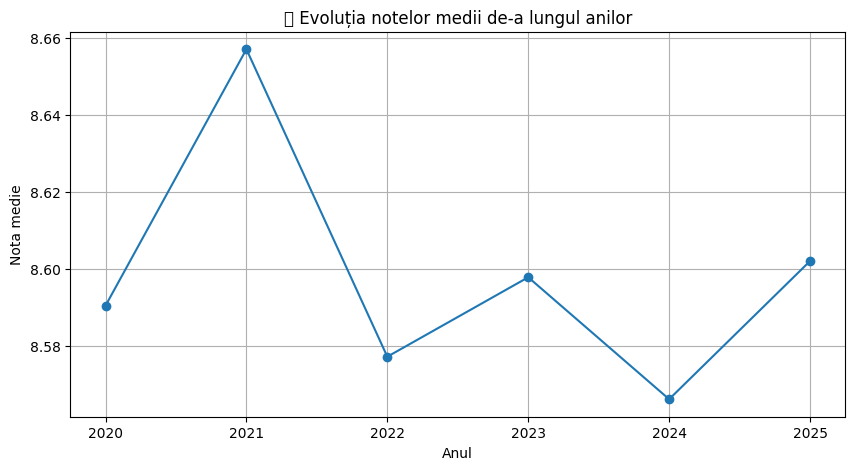

In [4]:
import matplotlib.pyplot as plt

# Ne asigurăm că data e în format datetime
df['date_added'] = pd.to_datetime(df['date_added'])

# Grupăm pe ani și calculăm media
df['year'] = df['date_added'].dt.year
ratings_by_year = df.groupby('year')['rating'].mean()

# Afișăm graficul
plt.figure(figsize=(10, 5))
ratings_by_year.plot(marker='o')
plt.title('📈 Evoluția notelor medii de-a lungul anilor')
plt.xlabel('Anul')
plt.ylabel('Nota medie')
plt.grid(True)
plt.show()


C:\Users\vladu\AppData\Local\Temp\ipykernel_16340\2683094981.py:12: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\vladu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


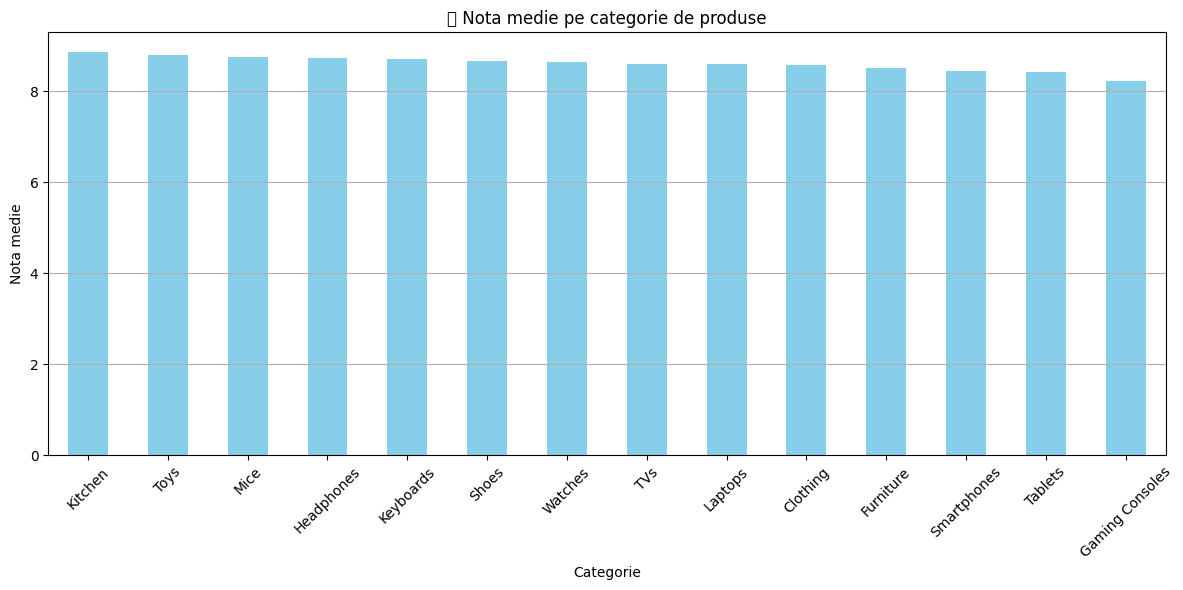

In [5]:
# Calculăm nota medie pe categorie
ratings_by_category = df.groupby('category')['rating'].mean().sort_values(ascending=False)

# Grafic
plt.figure(figsize=(12, 6))
ratings_by_category.plot(kind='bar', color='skyblue')
plt.title('📊 Nota medie pe categorie de produse')
plt.xlabel('Categorie')
plt.ylabel('Nota medie')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## 📌 Concluzii

- Nota maximă acordată unui produs este `X`, iar nota minimă este `Y`.
- Se observă că evaluările medii au evoluat (crescut/scăzut/stagnat) în perioada analizată.
- Categoriile cele mai apreciate sunt cele cu nota medie ridicată – acestea pot fi promovate mai intens.
- Aceste date oferă indicii valoroase pentru echipa de marketing în deciziile privind achizițiile și promovările.

👉 Următorul pas ar putea fi corelarea notelor cu prețul, numărul de review-uri sau sezonalitatea.
